## Python For Machine Learning Fall 2025
---
# Tree-based ML Models

# 1. Decision Tree

A Decision Tree is a supervised machine learning algorithm that can be used for both classification and regression tasks. It's a flowchart-like structure where each internal node represents a "test" on an attribute (e.g., whether a coin flip comes up heads or tails), each branch represents the outcome of the test, and each leaf node represents a class label (decision taken after computing all attributes). The paths from the root to a leaf represent classification rules.

---
## 1.1 Tree structure

A tree is a very common data structure. Let us create a plot that shows only its structure, without considering the actual data.



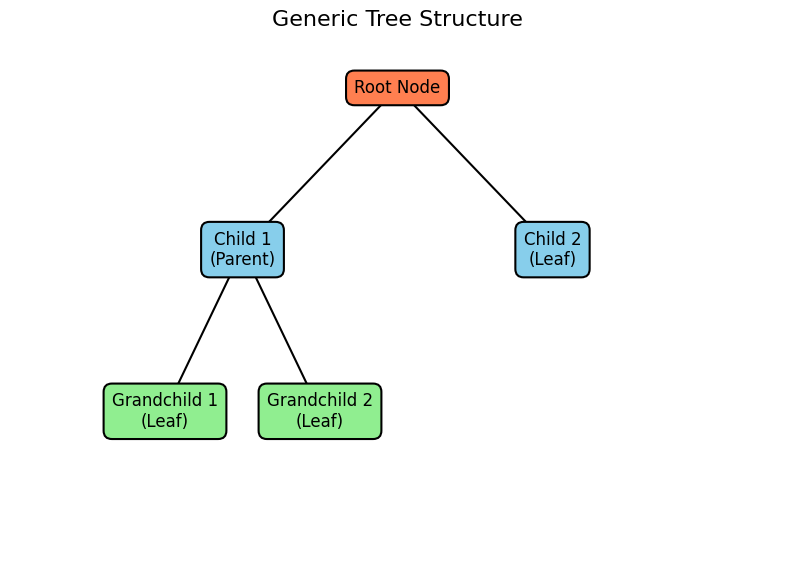

In [ ]:
import matplotlib.pyplot as plt

nodes = {
    'A': {'label': 'Root Node', 'pos': (0.5, 0.9), 'color': 'coral'},
    'B': {'label': 'Child 1\n(Parent)', 'pos': (0.3, 0.6), 'color': 'skyblue'},
    'C': {'label': 'Child 2\n(Leaf)', 'pos': (0.7, 0.6), 'color': 'skyblue'},
    'D': {'label': 'Grandchild 1\n(Leaf)', 'pos': (0.2, 0.3), 'color': 'lightgreen'},
    'E': {'label': 'Grandchild 2\n(Leaf)', 'pos': (0.4, 0.3), 'color': 'lightgreen'}
}

edges = [('A', 'B'), ('A', 'C'), ('B', 'D'), ('B', 'E')]

fig, ax = plt.subplots(figsize=(10, 7))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

for start_node, end_node in edges:
    start_pos = nodes[start_node]['pos']
    end_pos = nodes[end_node]['pos']
    ax.plot([start_pos[0], end_pos[0]], [start_pos[1], end_pos[1]], 'k-', lw=1.5, zorder=1)

bbox_props = dict(boxstyle="round,pad=0.5", ec="black", lw=1.5)

for node_id, node_info in nodes.items():
    ax.text(node_info['pos'][0], node_info['pos'][1], node_info['label'],
            ha="center", va="center",
            size=12,
            bbox={**bbox_props, 'fc': node_info['color']},
            zorder=2)

ax.set_title("Generic Tree Structure", fontsize=16)
ax.axis('off')

plt.show()

The tree structure shown is a binary tree, which is the standard implementation in modern machine learning frameworks. Therefore, in practical applications, the decision trees you work with will almost always be binary trees.

---
## 1.2 Decision Tree Example

A decision tree's fundamental concept is straightforward, much like a flowchart that maps out a decision-making process.

Let's consider a simple dataset to decide whether to play tennis based on the weather conditions. Our goal is to predict the `Play` decision.

| Outlook | Temp | Humidity | Windy | Play |
| :--- | :---: | :---: | :---: | :---: |
| Sunny | Hot | High | False | No |
| Sunny | Hot | High | True | No |
| Overcast | Hot | High | False | Yes |
| Rainy | Mild | High | False | Yes |
| Rainy | Cool| Normal| False | Yes |
| Rainy | Cool| Normal| True | No |
| Overcast | Cool| Normal| True | Yes |
| Sunny | Mild | High | False | No |
| Sunny | Cool| Normal| False | Yes |
| Rainy | Mild | Normal| False | Yes |
| Sunny | Mild | Normal| True | Yes |
| Overcast | Mild | High | True | Yes |
| Overcast | Hot | Normal| False | Yes |
| Rainy | Mild | High | True | No |

### 1.2.1 Finding the First Split

First, the tree must find the single best question to ask at the start. It looks at all four features (`Outlook`, `Temp`, `Humidity`, `Windy`) to see which one does the best job of separating the "Yes" and "No" outcomes. The "best" split is the one that creates the most **pure** subgroups, a concept measured by metrics like Information Gain or Gini Impurity.

Let's evaluate our options:

- If we split by `Outlook`:

    - Sunny (5 days): 2 Yes, 3 No (Mixed)

    - Overcast (4 days): 4 Yes, 0 No (Perfectly Pure!)

    - Rainy (5 days): 3 Yes, 2 No (Mixed)

- If we split by Humidity:

    - High (7 days): 3 Yes, 4 No (Very Mixed)

    - Normal (7 days): 6 Yes, 1 No (Mostly Pure)

Splitting by Outlook is the clear winner because it immediately creates a perfectly pure group (Overcast always leads to Play = Yes). No other feature does this so effectively. Therefore, Outlook is the root of our tree.

### 1.2.2 Continuing the Splits (Recursion)

Now that we have our first split, we have three branches. The `Overcast` branch is finished, but the `Sunny` and `Rainy` branches are still mixed, so we repeat the process on those smaller datasets.

On the `Sunny` Branch...
We only look at the 5 days where `Outlook` was `Sunny`. On these days, which question best separates the 2 "Yes" from the 3 "No" outcomes? The algorithm finds that the next best question is about `Humidity`.

- If `Outlook` is `Sunny` and `Humidity` is High: All 3 instances are No. (Pure!)

- If `Outlook` is `Sunny` and `Humidity` is Normal: Both 2 instances are Yes. (Pure!)

This perfectly separates the data, so we stop splitting on this branch.

On the `Rainy` Branch...
We look at the 5 days where `Outlook` was `Rainy`. Which question best separates the 3 "Yes" from the 2 "No" outcomes? The algorithm finds that the best question is about `Windy`.

- If Outlook is `Rainy` and `Windy` is False: All 3 instances are Yes. (Pure!)

- If `Outlook` is `Rainy` and `Windy` is True: Both 2 instances are No. (Pure!)

This also perfectly separates the data. Now all branches end in a pure "leaf" node.

### 1.2.3 The Final Decision Tree

Putting it all together, the finished decision tree looks like the flowchart below.

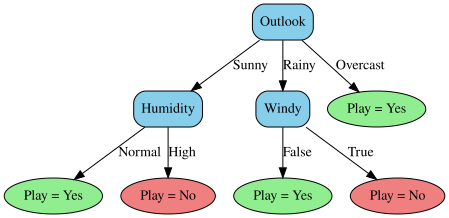

In [ ]:
from graphviz import Digraph

dot = Digraph(comment='Simple Play Tennis Decision Tree')
dot.attr(rankdir='TB')

dot.attr('node', shape='box', style='rounded,filled', fillcolor='skyblue')

dot.node('outlook', 'Outlook')
dot.node('humidity', 'Humidity')
dot.node('windy', 'Windy')

dot.node('play_yes_1', 'Play = Yes', shape='ellipse', fillcolor='lightgreen')
dot.node('play_yes_2', 'Play = Yes', shape='ellipse', fillcolor='lightgreen')
dot.node('play_yes_3', 'Play = Yes', shape='ellipse', fillcolor='lightgreen')
dot.node('play_no_1', 'Play = No', shape='ellipse', fillcolor='lightcoral')
dot.node('play_no_2', 'Play = No', shape='ellipse', fillcolor='lightcoral')

dot.edge('outlook', 'play_yes_1', label='Overcast')
dot.edge('outlook', 'humidity',   label='Sunny')
dot.edge('outlook', 'windy',      label='Rainy')

dot.edge('humidity', 'play_no_1',  label='High')
dot.edge('humidity', 'play_yes_2', label='Normal')

dot.edge('windy', 'play_no_2',  label='True')
dot.edge('windy', 'play_yes_3', label='False')

dot

This tree represents the rules the algorithm learned from your data.

### 1.2.4 Gini Impurity

What is Gini Impurity?

Gini Impurity is a measurement of how "mixed up" a collection of items is. It's a key concept for **CART** (Classification and Regression Trees) decision trees.

Think of it like a jar of marbles.
* **Low Gini Impurity (Pure):** A jar containing only blue marbles is perfectly pure. It has a Gini score of **0**.
* **High Gini Impurity (Impure):** A jar with an equal number of blue and red marbles is maximally mixed up. For two classes, its Gini score is **0.5**.

In a decision tree, our goal at each split is to decrease impurity as much as possible. We want to ask questions that result in child nodes that are "purer" than the parent node.

The formula for Gini Impurity is simple and elegant:

$$ Gini = 1 - \sum_{i=1}^{c} (p_i)^2 $$

Where:
* **c** is the total number of classes (e.g., "Play=Yes" and "Play=No", so c=2).
* **$p_i$** is the probability of an item being classified into class *i*. This is calculated as
$$
p_i=\frac{number \space of \space items \space in \space class \space i}{total \space number \space of \space items}
$$
Essentially, it calculates the probability of incorrectly classifying a randomly chosen element if it were randomly labeled according to the distribution of labels in the subset.

Let's use a node from our "Play Tennis" dataset. Imagine a node that contains **5** data points:
* **3** instances of `Play = No`
* **2** instances of `Play = Yes`

**Step 1: Calculate the probabilities ($p_i$)**
* p(No) = 3 / 5 = 0.6
* p(Yes) = 2 / 5 = 0.4

**Step 2: Plug them into the formula**
* Gini = 1 - [ (p(No))² + (p(Yes))² ]
* Gini = 1 - [ (0.6)² + (0.4)² ]
* Gini = 1 - [ 0.36 + 0.16 ]
* Gini = 1 - 0.52
* **Gini = 0.48**

This score of **0.48** is very close to the maximum impurity of 0.5, which makes sense because the classes are not well separated.

Calculating Gini impurity is straightforward in Python or any other programming language. Let's define a function to caluclate the value.

In [ ]:
import numpy as np
# Your implementation here


In [ ]:
# Test the function
example_node = ['No', 'No', 'No', 'Yes', 'Yes']
gini_score = calculate_gini(example_node)

print(f"The labels are: {example_node}")
print(f"The calculated Gini Impurity is: {gini_score:.2f}")

# --- Test a pure node ---
pure_node = ['Yes', 'Yes', 'Yes', 'Yes']
pure_gini_score = calculate_gini(pure_node)
print(f"\nThe labels are: {pure_node}")
print(f"The Gini Impurity of a pure node is: {pure_gini_score:.2f}")

The labels are: ['No', 'No', 'No', 'Yes', 'Yes']
The calculated Gini Impurity is: 0.48

The labels are: ['Yes', 'Yes', 'Yes', 'Yes']
The Gini Impurity of a pure node is: 0.00


---
# 2. CART



**CART**, which stands for **C**lassification **A**nd **R**egression **T**ree, is a widely used algorithm for building decision trees. It's the engine behind the decision tree implementations in `sklearn`.

What makes CART distinct from other tree algorithms (like ID3 or C4.5) are three key characteristics:

1.  **It builds Binary Trees:** Every split in a CART tree results in exactly two branches (a "yes/no" answer). This makes the trees simple and efficient. For a feature like "Outlook" with three values {Sunny, Overcast, Rainy}, CART would create a split like "Is Outlook = Overcast?" versus "Is Outlook != Overcast?".

2.  **It's a Dual-Purpose Algorithm:** As the name suggests, it can be used for both:
    * **Classification:** Predicting a category (e.g., "Play Tennis" or "Don't Play").
    * **Regression:** Predicting a continuous value (e.g., the price of a house).

3.  **It uses specific splitting criteria:**
    * For **Classification**, it uses **Gini Impurity** to measure the "purity" of the nodes.
    * For **Regression**, it uses **Mean Squared Error (MSE)** to measure how well a split reduces the variance in the target values.


***
### 2.1 CART for Classification

Classification trees are used when the target variable is categorical. The goal is to create a model that predicts the value of a target variable by learning simple decision rules inferred from the data features. The leaves of the tree represent the class labels.

When used for classification, the CART algorithm's main goal is to find the splits that create the purest possible child nodes.

At each node, the algorithm iterates through every feature and every possible split point for that feature. For each potential split, it calculates the **weighted Gini Impurity** of the two resulting child nodes.

The algorithm then chooses the single split that results in the **lowest** weighted Gini score, as this represents the biggest "purity gain."

* **For Numerical Features (e.g., Temperature):** It will test thresholds like `Temp <= 75`, `Temp <= 80`, etc., to find the best value to split on.
* **For Categorical Features (e.g., Outlook):** It will test splits like `Outlook == Sunny` vs. `Outlook != Sunny`, finding the subset that best separates the data.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [ ]:
print("### CART for Classification ###")
# Sample Data: [Hours Studied, Hours Slept] -> Pass (1) or Fail (0)
X_class = np.array([[2, 8], [8, 9], [1, 4], [9, 10], [5, 6], [3, 7]])
y_class = np.array([0, 1, 0, 1, 0, 1])

In [ ]:
# Define and train your decision tree classifier using sklearn


### CART for Classification ###


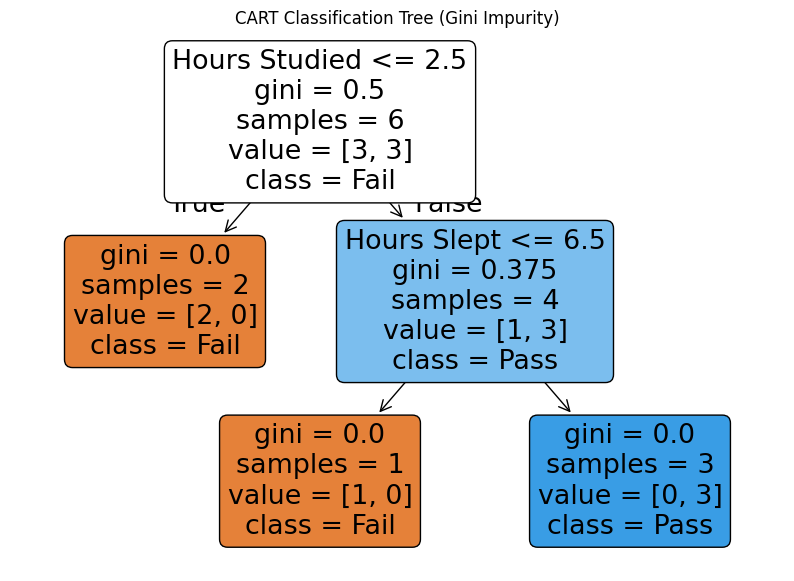

In [ ]:
# Visualize the tree
plt.figure(figsize=(10, 7))
plot_tree(cart_classifier, feature_names=['Hours Studied', 'Hours Slept'], class_names=['Fail', 'Pass'], filled=True, rounded=True)
plt.title("CART Classification Tree (Gini Impurity)")
plt.show()

## 2.2 CART for Regression: Minimizing Variance (MSE)

When used for regression, the goal shifts from "purity" to reducing "variance." We want the values within our leaf nodes to be as similar to each other as possible.

The CART algorithm uses **Mean Squared Error (MSE)** to measure this. MSE calculates the average squared difference between the actual values in a node and their mean.

$$ MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \bar{y})^2 $$

At each node, the algorithm searches for the feature and split point that results in the **lowest weighted MSE** across the two child nodes.

The final prediction for any given leaf node is simply the **average (mean)** of all the training samples' target values that ended up in that leaf.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree

In [ ]:
print("\n### CART for Regression ###")
# Sample Data: [Square Footage] -> House Price (in $1000s)
X_reg = np.array([[800], [1500], [2000], [1200], [2500], [1000]])
y_reg = np.array([150, 300, 450, 250, 500, 200])

In [ ]:
# define and train your decision tree regressor using sklearn



### CART for Regression ###


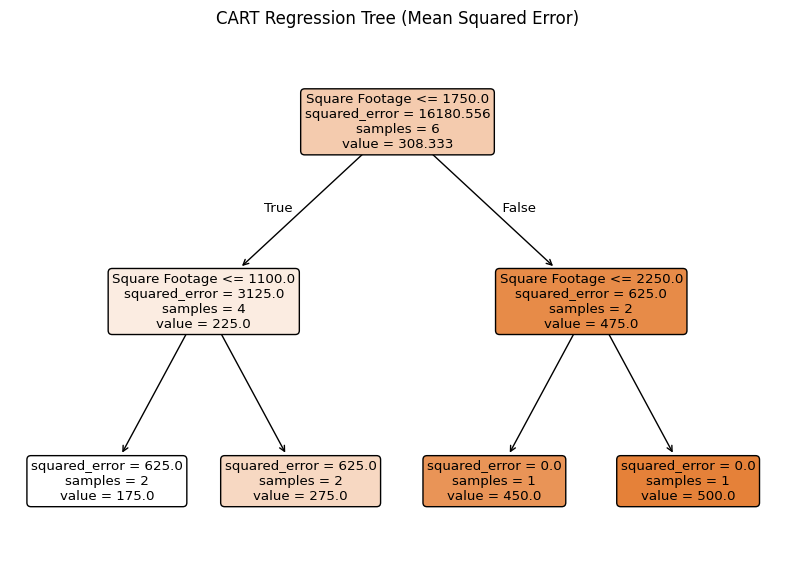

In [ ]:
# Visualize the tree
plt.figure(figsize=(10, 7))
plot_tree(cart_regressor, feature_names=['Square Footage'], filled=True, rounded=True)
plt.title("CART Regression Tree (Mean Squared Error)")
plt.show()

## 2.3 Greedy Search and the Risk of Overfitting

The CART algorithm is a **greedy algorithm**. This is a critical concept to understand because it's the primary reason why single decision trees are so prone to overfitting.

**What is a Greedy Algorithm?**

A greedy algorithm makes the *locally optimal* choice at each step, hoping that these local choices will lead to a *globally optimal* solution.

Imagine you're climbing a hill in the fog. A greedy approach would be to always take the steepest step upwards immediately in front of you. This might get you to the top of a small hill (a local optimum), but it could prevent you from finding the path to the highest peak in the entire mountain range (the global optimum).

**How is CART Greedy?**
At each node, the CART algorithm scans every feature and every possible split point. It greedily chooses the **single best split**—the one that provides the largest immediate reduction in impurity (Gini for classification, MSE for regression). It makes this choice without looking ahead to see if a slightly worse split now could lead to a much better tree overall.

**The Link to Overfitting**
This greedy, shortsighted focus on purity is what leads to overfitting. The algorithm will continue to make splits, subdividing the data until the leaf nodes are as pure as possible.

If left unconstrained, a CART tree will create an overly complex model that has essentially **"memorized" the training data**, including its noise and random quirks. This model will perform perfectly on the data it has already seen but will fail to generalize to new, unseen data.


*An overfit model creates a complex decision boundary that captures noise rather than the underlying trend.*

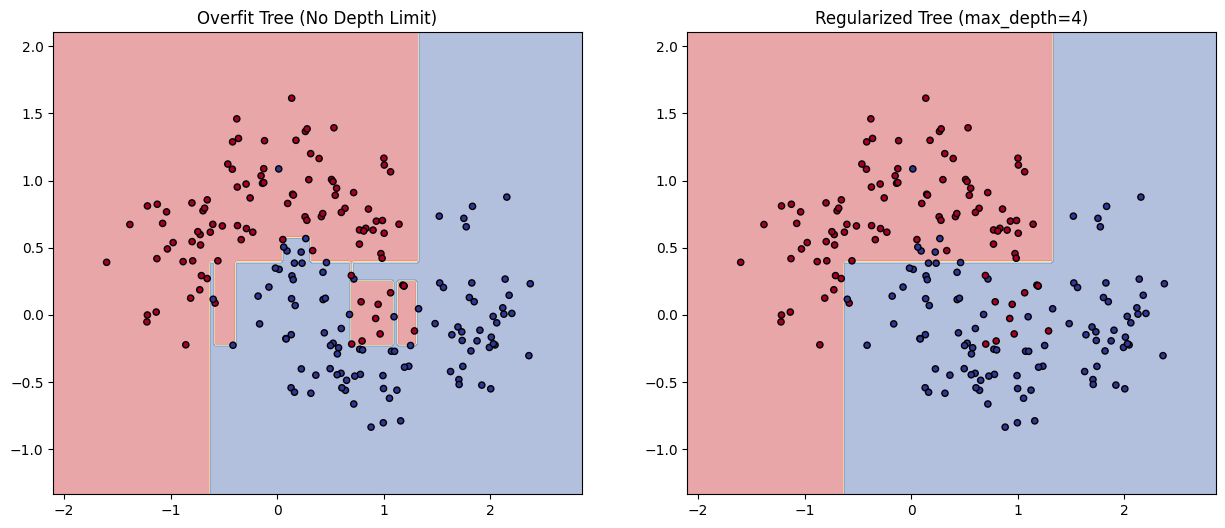

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier

# 1. Generate a noisy, non-linear dataset
X, y = make_moons(n_samples=200, noise=0.25, random_state=42)

# 2. Train two CART models
#    - An unconstrained, overfit tree
#    - A regularized tree with a depth limit (pre-pruning)
overfit_tree = DecisionTreeClassifier(random_state=42)
regularized_tree = DecisionTreeClassifier(max_depth=4, random_state=42)

overfit_tree.fit(X, y)
regularized_tree.fit(X, y)

# Helper function to plot the decision boundary
def plot_decision_boundary(clf, X, y, ax, title):
    # Create a grid of points
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    # Predict the classification for each point on the grid
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot the colored regions and the data points
    ax.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.RdYlBu)
    ax.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k', cmap=plt.cm.RdYlBu)
    ax.set_title(title)

# 3. Create the visualizations
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

plot_decision_boundary(overfit_tree, X, y, axes[0], "Overfit Tree (No Depth Limit)")
plot_decision_boundary(regularized_tree, X, y, axes[1], "Regularized Tree (max_depth=4)")

plt.show()

The visualization above clearly shows the effect of the greedy algorithm:
* **The Overfit Tree** on the left has a complex, jagged decision boundary. It has created many small regions to perfectly classify every single training point. It has learned the noise, not the underlying "moon" shape.
* **The Regularized Tree** on the right has a much smoother, more general boundary. By stopping the greedy process early (`max_depth=4`), we prevent it from fitting to the noise, resulting in a model that is much more likely to perform well on new data.


## 2.4 How to Control Overfitting

The tendency of greedy CART to overfit is a well-known weakness. The primary solutions are:
1.  **Pruning:** This involves constraining the tree's growth.
    * **Pre-Pruning (what we did above):** Stopping the tree from growing too deep by setting parameters like `max_depth`, `min_samples_leaf`, or `min_samples_split`.
    * **Post-Pruning:** Growing the tree fully and then removing branches that provide little statistical value.

2.  **Ensemble Methods (The Modern Solution):** Instead of trying to perfect a single tree, we can combine many of them. The flaws and errors of individual greedy trees tend to cancel each other out.
    * **Random Forests:** Builds many deep trees on random subsets of data and features, then averages their predictions.
    * **Gradient Boosting (e.g., XGBoost, LightGBM):** Builds trees sequentially, where each new tree is trained to correct the errors of the previous ones.